# Analyse RSSI en fonction de la fréquence

Objectif : voir si le RSSI varie de façon structurée selon la fréquence, et quelle représentation est la plus pratique pour la suite.



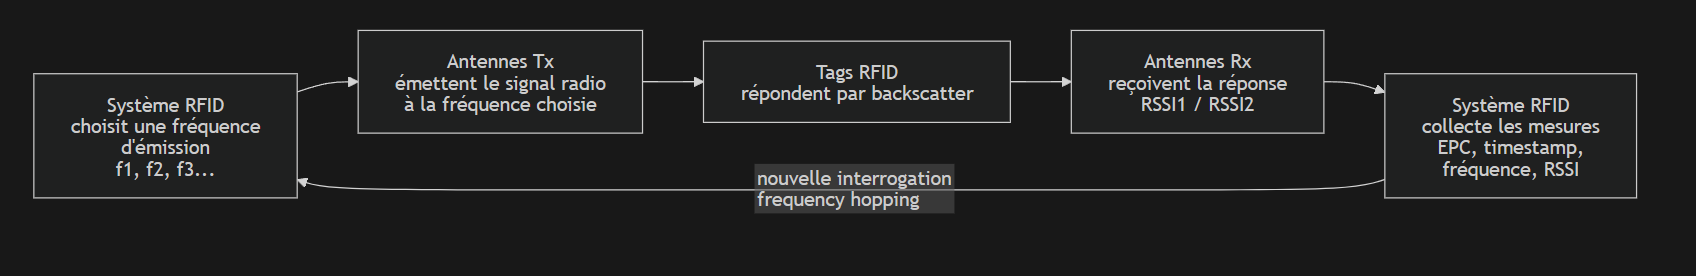

In [2]:
import base64
from IPython.display import HTML


with open("graph.png","rb") as f:
    b64 = base64.b64encode(f.read()).decode()
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

Ci dessous, je graph de la présentation, avec mis dans la boucle le frequency hopping, introduit par M. loussert dans les dernieres visioconférences.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 140)

DATA_PATH = Path("tags_pick_power_tx_rx_freq.csv")
assert DATA_PATH.exists(), f"Fichier introuvable: {DATA_PATH.resolve()}"


## 1. Lecture du dataset brut

On commence par vérifier la structure du fichier et les colonnes utiles.


In [2]:
usecols = [
    "run",
    "datestamp",
    "freq_MHz",
    "EPC",
    "txPower_dBm",
    "Tx",
    "rx",
    "rssi (dBm)",
    "x",
    "y",
    "z",
    "polar",
]

raw = pd.read_csv(DATA_PATH, usecols=usecols)

print(f"Lignes : {len(raw):,}")
print(f"Nombre de fréquences distinctes : {raw['freq_MHz'].nunique()}")
print(f"Bande fréquentielle : {raw['freq_MHz'].min()} MHz -> {raw['freq_MHz'].max()} MHz")
print()
print("Colonnes utilisées :")
print(raw.columns.tolist())
print()
raw.head()


Nombre total de lignes : 703,788
Nombre de fréquences distinctes : 50
Bande fréquentielle : 902.75 MHz -> 927.25 MHz

Colonnes utilisées :
['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx', 'rx', 'rssi (dBm)', 'x', 'y', 'z', 'polar']



,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),x,y,z,polar
0,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,1.82,2.51,1.34,V
1,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_4__NONE,-83.32,1.82,2.51,1.34,V
2,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0604000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-76.42,1.82,2.51,1.67,H
3,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0604000000000000000000,31.5,041A9F60__NONE,PORT_4__NONE,-75.39,1.82,2.51,1.67,H
4,2026-02-04 21:23:51,2026-02-04 21:23:50.648,907.75,BA0508000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-76.44,1.82,2.51,1.34,V


## 2. Format du fichier

Le fichier est déjà exploitable : la colonne `freq_MHz` permet de travailler en format long, puis de reconstruire une séquence ordonnée par fréquence.

Pour définir un sample, je garde `EPC`, `txPower_dBm`, `Tx`, `rx`, `x`, `y`, `z`.


In [3]:
SAMPLE_KEYS = ["EPC", "txPower_dBm", "Tx", "rx", "x", "y", "z"]
TARGET_COL = "rssi (dBm)"

sample_count = raw[SAMPLE_KEYS].drop_duplicates().shape[0]
print(f"Nombre d'échantillons logiques (sans la fréquence) : {sample_count:,}")

freq_per_sample = raw.groupby(SAMPLE_KEYS, dropna=False)["freq_MHz"].nunique()
coverage_stats = (freq_per_sample / raw["freq_MHz"].nunique()).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

print()
print("Nombre de fréquences disponibles par échantillon :")
print(freq_per_sample.describe())
print()
print("Couverture fréquentielle (proportion des 50 canaux présents) :")
print(coverage_stats)
print()
print(f"Echantillons avec au moins 5 fréquences : {(freq_per_sample >= 5).sum():,}")
print(f"Echantillons avec au moins 10 fréquences : {(freq_per_sample >= 10).sum():,}")
print(f"Echantillons avec au moins 20 fréquences : {(freq_per_sample >= 20).sum():,}")


Nombre d'échantillons logiques (sans la fréquence) : 183,273

Nombre de fréquences disponibles par échantillon :
count    183273.000000
mean          3.645878
std           2.933308
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          25.000000
Name: freq_MHz, dtype: float64

Couverture fréquentielle (proportion des 50 canaux présents) :
count    183273.000000
mean          0.072918
std           0.058666
min           0.020000
10%           0.020000
25%           0.040000
50%           0.060000
75%           0.100000
90%           0.140000
max           0.500000
Name: freq_MHz, dtype: float64

Echantillons avec au moins 5 fréquences : 51,501
Echantillons avec au moins 10 fréquences : 8,544
Echantillons avec au moins 20 fréquences : 225


In [7]:
freq_per_sample.head(20)

EPC                       txPower_dBm  Tx              rx            x     y     z   
BA0101000000000000000000  24.0         041A9F60__NONE  PORT_1__NONE  3.33  3.14  0.05    1
                                                                           3.58  1.19    1
                                                                     3.61  2.39  1.92    4
                                                                     4.41  2.39  0.74    4
                                                                     4.42  2.39  0.73    6
                                                                     5.68  3.49  0.05    3
                                                       PORT_2__NONE  3.32  3.60  1.20    3
                                                                     3.33  3.14  0.05    1
                                                                     3.36  3.56  1.18    1
                                                                     3.61  2.39  1.92    3
    

## 3. Passage en séquence

Il y a quelques doublons sur `(sample, fréquence)`, donc je prends la moyenne du RSSI.

Je garde ensuite deux vues :

- `agg_long` pour les graphes ;
- `wide` pour les corrélations et la vue par fréquence.


In [8]:
agg_long = (
    raw.groupby(SAMPLE_KEYS + ["freq_MHz"], dropna=False)[TARGET_COL]
    .mean()
    .reset_index()
    .sort_values(SAMPLE_KEYS + ["freq_MHz"])
)

wide = (
    agg_long.pivot_table(
        index=SAMPLE_KEYS,
        columns="freq_MHz",
        values=TARGET_COL,
        aggfunc="mean",
    )
    .sort_index(axis=1)
)

sample_info = wide.notna().sum(axis=1).rename("n_freq").to_frame()
sample_info["coverage_ratio"] = sample_info["n_freq"] / wide.shape[1]

X_seq_raw = wide.to_numpy(dtype=float)
X_mask = ~np.isnan(X_seq_raw)
sample_mean = np.nanmean(X_seq_raw, axis=1, keepdims=True)
sample_std = np.nanstd(X_seq_raw, axis=1, keepdims=True)
sample_std[sample_std == 0] = np.nan
X_seq_zscore = (X_seq_raw - sample_mean) / sample_std

print(f"Forme de la matrice séquentielle : {wide.shape[0]:,} samples x {wide.shape[1]} fréquences")
print(f"Taux de valeurs manquantes : {1 - X_mask.mean():.2%}")
print()
print("Exemple de matrice séquentielle (5 premières lignes) :")
wide.head()


Forme de la matrice séquentielle : 183,273 samples x 50 fréquences
Taux global de valeurs manquantes : 92.71%

Exemple de matrice séquentielle (5 premières lignes) :


freq_MHz                                                                         902.75  903.25  903.75  904.25  904.75  905.25  905.75  \
EPC                      txPower_dBm Tx             rx           x    y    z                                                              
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                      3.58 1.19     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 3.61 2.39 1.92     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 4.41 2.39 0.74     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 4.42 2.39 0.73     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

freq_MHz                                                                         906.25  906.75  907.25  907.75  908.25  908.75  909.25  \
EPC                      txPower_dBm Tx             rx           x    y    z                                                              
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                      3.58 1.19     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 3.61 2.39 1.92     NaN     NaN  -75.76     NaN     NaN     NaN     NaN   
                                                                 4.41 2.39 0.74     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 4.42 2.39 0.73     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

freq_MHz                                                                         909.75  910.25  910.75  911.25  911.75  912.25  912.75  \
EPC                      txPower_dBm Tx             rx           x    y    z                                                              
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                      3.58 1.19     NaN     NaN     NaN  -67.99     NaN     NaN     NaN   
                                                                 3.61 2.39 1.92     NaN     NaN  -75.78     NaN     NaN     NaN     NaN   
                                                                 4.41 2.39 0.74     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 4.42 2.39 0.73     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

freq_MHz                                                                         913.25  913.75  914.25  914.75  915.25  915.75  916.25  \
EPC                      txPower_dBm Tx             rx           x    y    z                                                              
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                      3.58 1.19     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 3.61 2.39 1.92     NaN     NaN     NaN  -76.22     NaN     NaN     NaN   
                                                                 4.41 2.39 0.74     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
                                                                 4.42 2.39 0.73     NaN     NaN     NaN     NaN  -69.45  -68.41  -68.03   

freq_MHz                                                                         916.75  917.25  917.75 

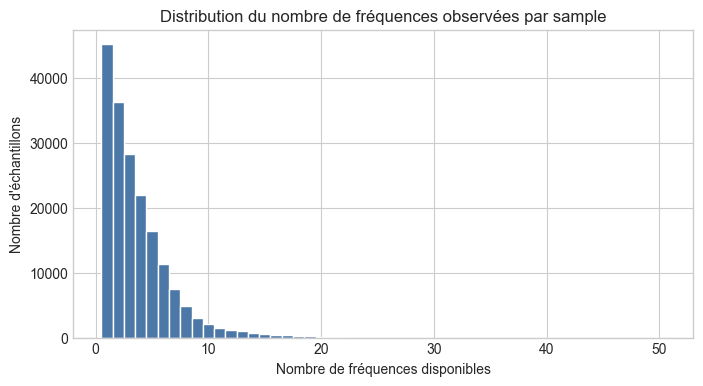

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_info["n_freq"], bins=np.arange(1, wide.shape[1] + 2) - 0.5, color="#4C78A8", edgecolor="white")
ax.set_title("Distribution du nombre de fréquences observées par sample")
ax.set_xlabel("Nombre de fréquences disponibles")
ax.set_ylabel("Nombre d'échantillons")
plt.show()


## 4. Quelques profils RSSI selon la fréquence

Je prends quelques samples avec une couverture correcte pour voir la forme des courbes.


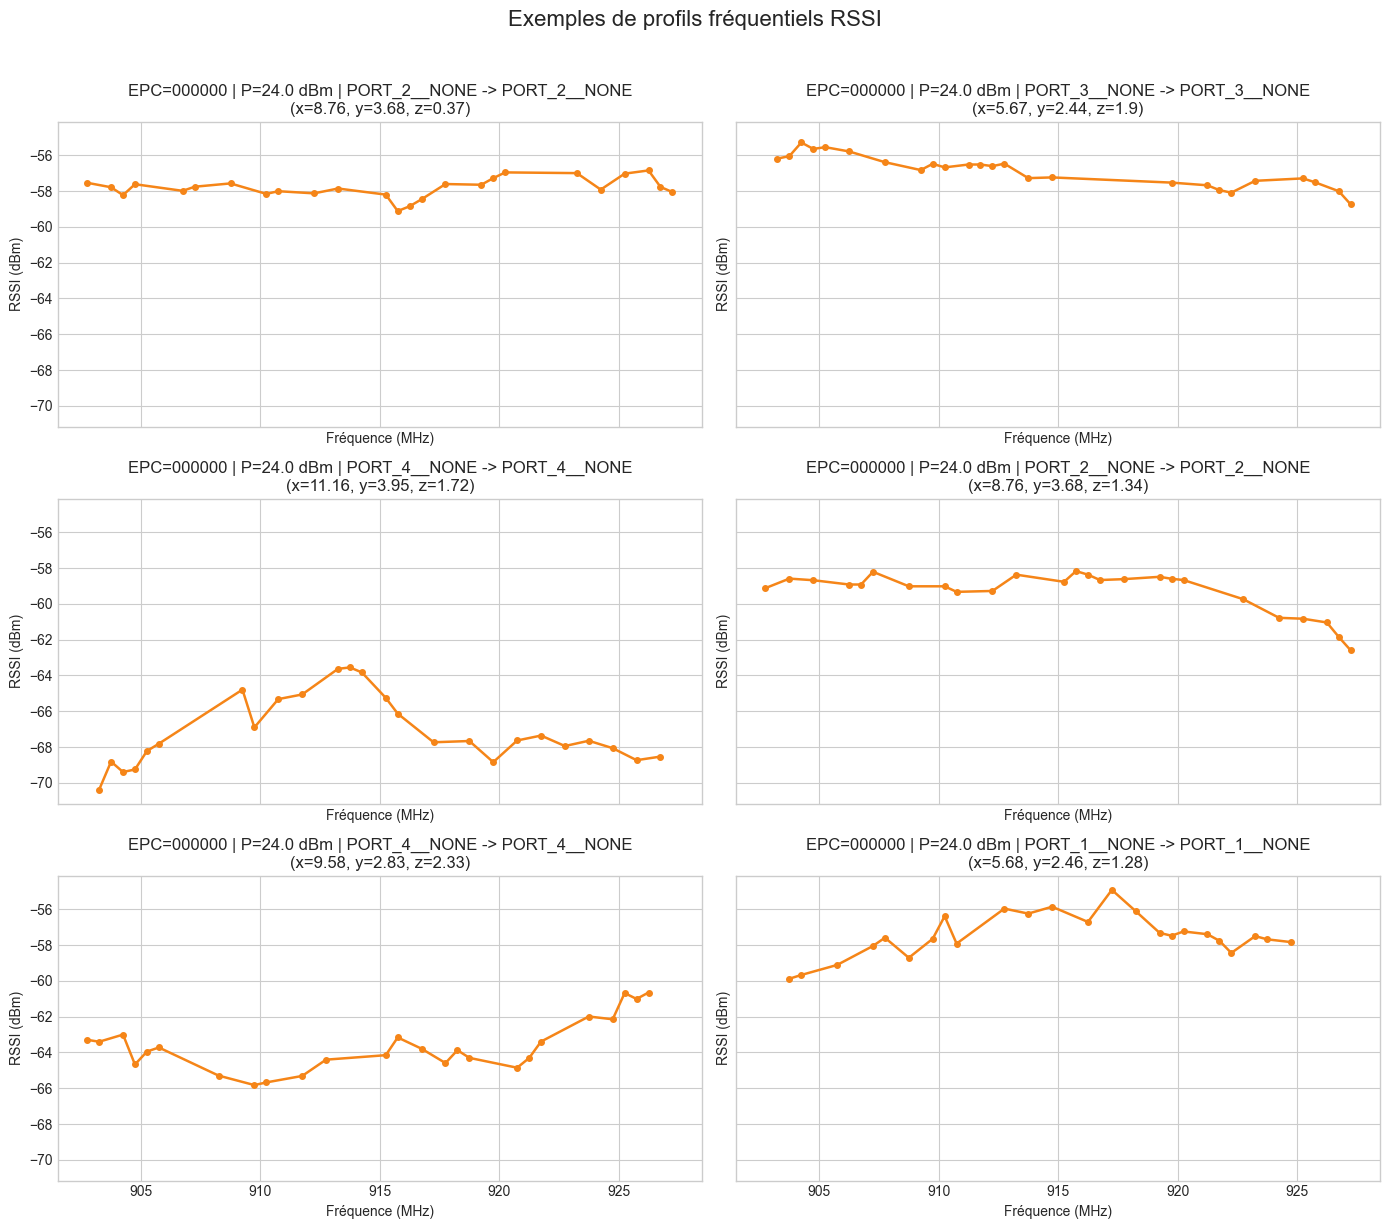

In [10]:
representative_samples = sample_info.sort_values(["n_freq", "coverage_ratio"], ascending=False).head(6).index

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.ravel()

for ax, idx in zip(axes, representative_samples):
    series = wide.loc[idx].dropna()
    ax.plot(series.index, series.values, marker="o", linewidth=1.8, markersize=4, color="#F58518")
    epc, power, tx, rx_ant, x, y, z = idx
    ax.set_title(f"EPC={epc[-6:]} | P={power} dBm | {tx} -> {rx_ant}\n(x={x}, y={y}, z={z})")
    ax.set_xlabel("Fréquence (MHz)")
    ax.set_ylabel("RSSI (dBm)")

fig.suptitle("Exemples de profils fréquentiels RSSI", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


## 5. Corrélation entre fréquences voisines

Ici je regarde si deux canaux adjacents ont tendance à évoluer ensemble.


In [11]:
freqs = list(wide.columns)
neighbor_rows = []

for i in range(len(freqs) - 1):
    f1 = freqs[i]
    f2 = freqs[i + 1]
    s1 = wide[f1]
    s2 = wide[f2]
    mask = s1.notna() & s2.notna()
    n_pairs = int(mask.sum())
    corr = s1[mask].corr(s2[mask]) if n_pairs >= 3 else np.nan
    neighbor_rows.append({"f1": f1, "f2": f2, "n_pairs": n_pairs, "corr": corr})

neighbor_corr = pd.DataFrame(neighbor_rows)

print("Résumé des corrélations entre fréquences voisines :")
print(neighbor_corr["corr"].describe())
print()
print("Paires les moins corrélées :")
print(neighbor_corr.nsmallest(5, "corr"))
print()
print("Paires les plus corrélées :")
print(neighbor_corr.nlargest(5, "corr"))


Résumé des corrélations entre fréquences voisines :
count    49.000000
mean      0.950178
std       0.006759
min       0.933757
25%       0.946570
50%       0.950893
75%       0.954016
max       0.963999
Name: corr, dtype: float64

Paires les moins corrélées :
        f1      f2  n_pairs      corr
20  912.75  913.25     1872  0.933757
18  911.75  912.25     1672  0.937197
17  911.25  911.75     1926  0.937459
44  924.75  925.25     1463  0.937545
41  923.25  923.75     1343  0.938704

Paires les plus corrélées :
        f1      f2  n_pairs      corr
6   905.75  906.25     1493  0.963999
7   906.25  906.75     1705  0.963263
8   906.75  907.25     1498  0.961865
39  922.25  922.75     1573  0.959437
30  917.75  918.25     1200  0.958809


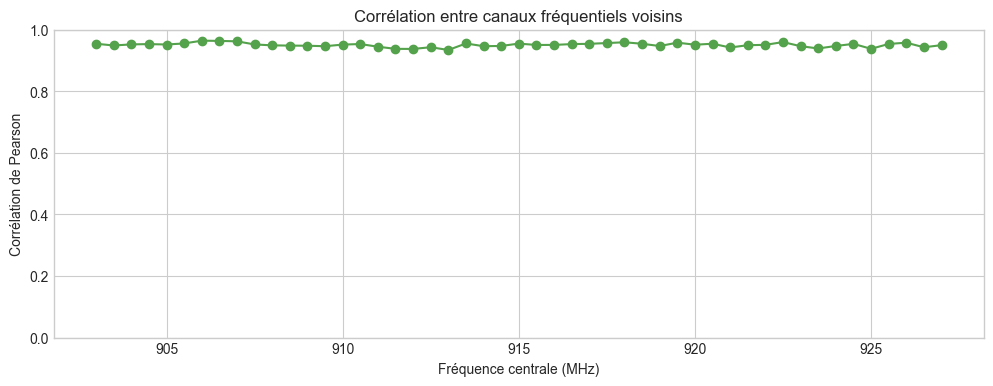

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 4))
mid_freq = (neighbor_corr["f1"] + neighbor_corr["f2"]) / 2

ax1.plot(mid_freq, neighbor_corr["corr"], marker="o", linewidth=1.5, color="#54A24B")
ax1.set_ylabel("Corrélation de Pearson")
ax1.set_xlabel("Fréquence centrale (MHz)")
ax1.set_title("Corrélation entre canaux fréquentiels voisins")
ax1.set_ylim(0, 1.0)
plt.show()


## 6. Autocorrélation

Je calcule ensuite une autocorrélation par sample pour voir jusqu'où la structure fréquentielle se propage.


In [9]:
def sample_autocorr(values: np.ndarray, lag: int, min_pairs: int = 3) -> float:
    left = values[:-lag]
    right = values[lag:]
    mask = ~np.isnan(left) & ~np.isnan(right)
    if mask.sum() < min_pairs:
        return np.nan
    x = left[mask]
    y = right[mask]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]


autocorr_rows = []
for lag in range(1, 11):
    per_sample = np.array([sample_autocorr(row, lag) for row in X_seq_zscore], dtype=float)
    valid = per_sample[~np.isnan(per_sample)]
    autocorr_rows.append(
        {
            "lag": lag,
            "n_samples": len(valid),
            "mean_autocorr": float(np.mean(valid)) if len(valid) else np.nan,
            "median_autocorr": float(np.median(valid)) if len(valid) else np.nan,
        }
    )

autocorr_df = pd.DataFrame(autocorr_rows)
autocorr_df


,lag,n_samples,mean_autocorr,median_autocorr
0,1,6704,0.545034,0.815245
1,2,9381,0.472310,0.734360
2,3,6161,0.462375,0.706993
3,4,8314,0.393469,0.617004
4,5,5541,0.353690,0.562422
5,6,7074,0.276094,0.452684
6,7,4949,0.249375,0.411933
7,8,6277,0.211023,0.332861
8,9,4495,0.172627,0.267663
9,10,5399,0.109552,0.167167


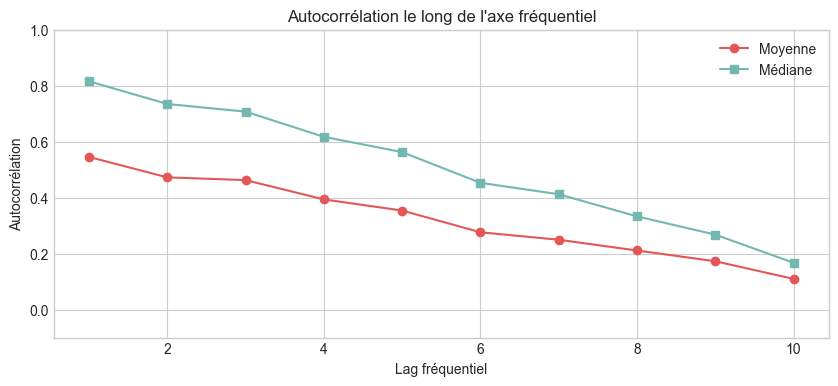

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(autocorr_df["lag"], autocorr_df["mean_autocorr"], marker="o", label="Moyenne", color="#E45756")
ax.plot(autocorr_df["lag"], autocorr_df["median_autocorr"], marker="s", label="Médiane", color="#72B7B2")
ax.set_title("Autocorrélation le long de l'axe fréquentiel")
ax.set_xlabel("Lag fréquentiel")
ax.set_ylabel("Autocorrélation")
ax.legend()
ax.set_ylim(-0.1, 1.0)
plt.show()


## 7. Comparaison avec un ordre mélangé

Je compare la variation réelle entre fréquences voisines avec la même chose après permutation aléatoire des fréquences.


In [11]:
rng = np.random.default_rng(0)
real_neighbor_diff = []
shuffled_neighbor_diff = []

for row in X_seq_raw:
    seq = row[~np.isnan(row)]
    if len(seq) < 5:
        continue
    real_neighbor_diff.append(np.mean(np.abs(np.diff(seq))))
    shuffled = seq.copy()
    rng.shuffle(shuffled)
    shuffled_neighbor_diff.append(np.mean(np.abs(np.diff(shuffled))))

smoothness_summary = pd.Series(
    {
        "n_samples_used": len(real_neighbor_diff),
        "mean_abs_diff_real": float(np.mean(real_neighbor_diff)),
        "mean_abs_diff_shuffled": float(np.mean(shuffled_neighbor_diff)),
        "ratio_real_over_shuffled": float(np.mean(real_neighbor_diff) / np.mean(shuffled_neighbor_diff)),
    }
)

smoothness_summary


n_samples_used              51501.000000
mean_abs_diff_real              2.160527
mean_abs_diff_shuffled          2.976489
ratio_real_over_shuffled        0.725864
dtype: float64

## 8. Représentation pour la suite

Le RSSI ne semble pas indépendant d'une fréquence à l'autre, donc une représentation ordonnée garde plus d'information. Comme le dataset est sparse, le plus simple est de garder le format long comme base et de construire une matrice fréquence + masque quand on veut travailler en séquence.


In [12]:
def build_sequence_features(wide_df: pd.DataFrame):
    """Construit une version sequence + masque."""
    x_raw = wide_df.to_numpy(dtype=float)
    mask = ~np.isnan(x_raw)

    row_mean = np.nanmean(x_raw, axis=1, keepdims=True)
    row_std = np.nanstd(x_raw, axis=1, keepdims=True)
    row_std[row_std == 0] = np.nan
    x_zscore = (x_raw - row_mean) / row_std

    summary = pd.DataFrame(index=wide_df.index)
    summary["n_freq"] = mask.sum(axis=1)
    summary["coverage_ratio"] = summary["n_freq"] / wide_df.shape[1]
    summary["rssi_mean"] = np.nanmean(x_raw, axis=1)
    summary["rssi_std"] = np.nanstd(x_raw, axis=1)
    summary["rssi_min"] = np.nanmin(x_raw, axis=1)
    summary["rssi_max"] = np.nanmax(x_raw, axis=1)
    summary["mean_abs_neighbor_diff"] = [
        np.nan if row_mask.sum() < 2 else np.mean(np.abs(np.diff(row[row_mask])))
        for row, row_mask in zip(x_raw, mask)
    ]

    return x_raw, x_zscore, mask.astype(np.int8), summary


X_raw, X_zscore, X_presence_mask, summary_features = build_sequence_features(wide)

print("Dimensions des tenseurs proposés :")
print(f"X_raw            : {X_raw.shape}")
print(f"X_zscore         : {X_zscore.shape}")
print(f"X_presence_mask  : {X_presence_mask.shape}")
print()
summary_features.head()


Dimensions des tenseurs proposés :
X_raw            : (183273, 50)
X_zscore         : (183273, 50)
X_presence_mask  : (183273, 50)



n_freq  coverage_ratio  rssi_mean  rssi_std  rssi_min  \
EPC                      txPower_dBm Tx             rx           x    y    z                                                             
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05       1            0.02 -72.280000  0.000000    -72.28   
                                                                      3.58 1.19       1            0.02 -67.990000  0.000000    -67.99   
                                                                 3.61 2.39 1.92       4            0.08 -74.015000  3.304675    -76.22   
                                                                 4.41 2.39 0.74       4            0.08 -67.772500  1.248066    -69.54   
                                                                 4.42 2.39 0.73       6            0.12 -68.483333  0.951239    -69.96   

                                                                                 rssi_max  mean_abs_neighbor_diff  
EPC                      txPower_dBm Tx             rx           x    y    z                                       
BA0101000000000000000000 24.0        041A9F60__NONE PORT_1__NONE 3.33 3.14 0.05    -72.28                     NaN  
                                                                      3.58 1.19    -67.99                     NaN  
                                                                 3.61 2.39 1.92    -68.30                2.793333  
                                                                 4.41 2.39 0.74    -66.14                2.120000  
                                                                 4.42 2.39 0.73    -67.16                1.376000

## 9. Bilan

Le format source convient déjà. Le RSSI garde une structure en fréquence, donc je ne le traiterais pas comme une simple liste de colonnes indépendantes. Pour la suite : format long en base, et matrice ordonnée + masque quand c'est utile.
